# Model Comparison


## Analysis Multivariate vs Univariate

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Import all_results.parquet file
df_results = pd.read_parquet("all_results.parquet")

#sort model for better visualization
model_order = ["MLP", "RNN", "LSTM", "GRU", "Transformer", "CNN1D", "NBEATS", "NBEATSx"]
df_results["Model"] = pd.Categorical(df_results["Model"], categories=model_order, ordered=True)

### Univariate Models

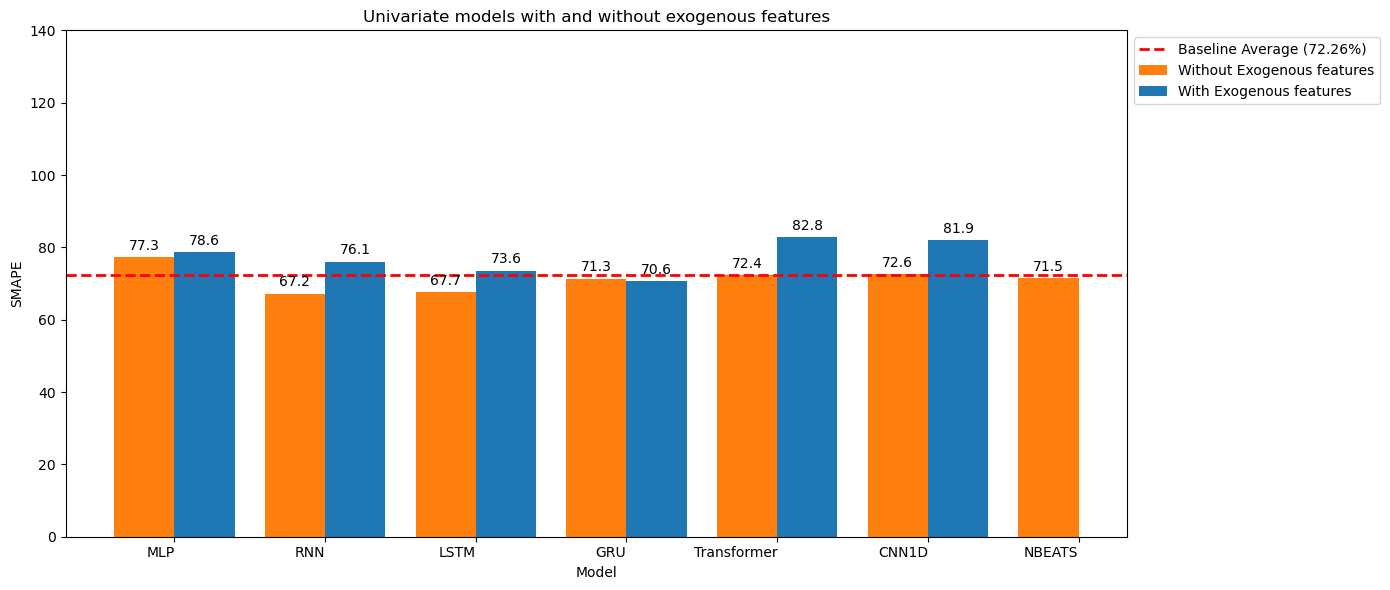

In [ ]:
df_plot_uni = df_results[(df_results["Fold"]=="Average") & (df_results["Approach"]=="Uni")].copy()

pivot = df_plot_uni.pivot_table(index="Model", columns="Features", values="SMAPE", aggfunc="mean", observed=True)

models = pivot.index.tolist()
x = np.arange(len(models))
width = 0.4

plt.figure(figsize=(14, 6))

bars_no = plt.bar(
    x - width/2,
    pivot["noExog"],
    width,
    label="Without Exogenous features",
    color="#ff7f0e"
)

bars_ex = plt.bar(
    x + width/2,
    pivot["Exog"],
    width,
    label="With Exogenous features",
    color="#1f77b4"
)

plt.axhline(
    y=72.26,
    linestyle="--",
    label="Baseline Average (72.26%)",
    linewidth=2,
    color="red"
)

plt.title("Univariate models with and without exogenous features")
plt.xticks(x, models, rotation=0, ha="right")
plt.xlabel("Model")
plt.ylabel("SMAPE")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 140)


plt.bar_label(bars_no, fmt="%.1f", padding=3)
plt.bar_label(bars_ex, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()


The figure above shows the error metrics (SMAPE) of all trained univariate models, representing the percentage forecasting error between observed and predicted values. The results are reported with exogenous features (blue) and without exogenous features (orange).

The best forecasting performance was achieved by the RNN (Recurrent Neural Network) without exogenous features, with an average SMAPE of 67.2%. Nevertheless, even this best-performing model only marginally outperforms the baseline model (SMAPE=72.3), which predicts future values using the mean of the three previous observations.

The highest SMAPE was observed for the Transformer model with exogenous features, indicating that this model is the least suitable for predicting vehicle registration numbers within the specified forecasting horizons.

Overall, most univariate models trained without exogenous features exhibit slightly better forecasting accuracy than their counterparts incorporating exogenous variables. The GRU (Gated Recurrent Unit) is the only model for which the inclusion of exogenous features results in a lower SMAPE compared to the version without exogenous features.

### Multivariate Models

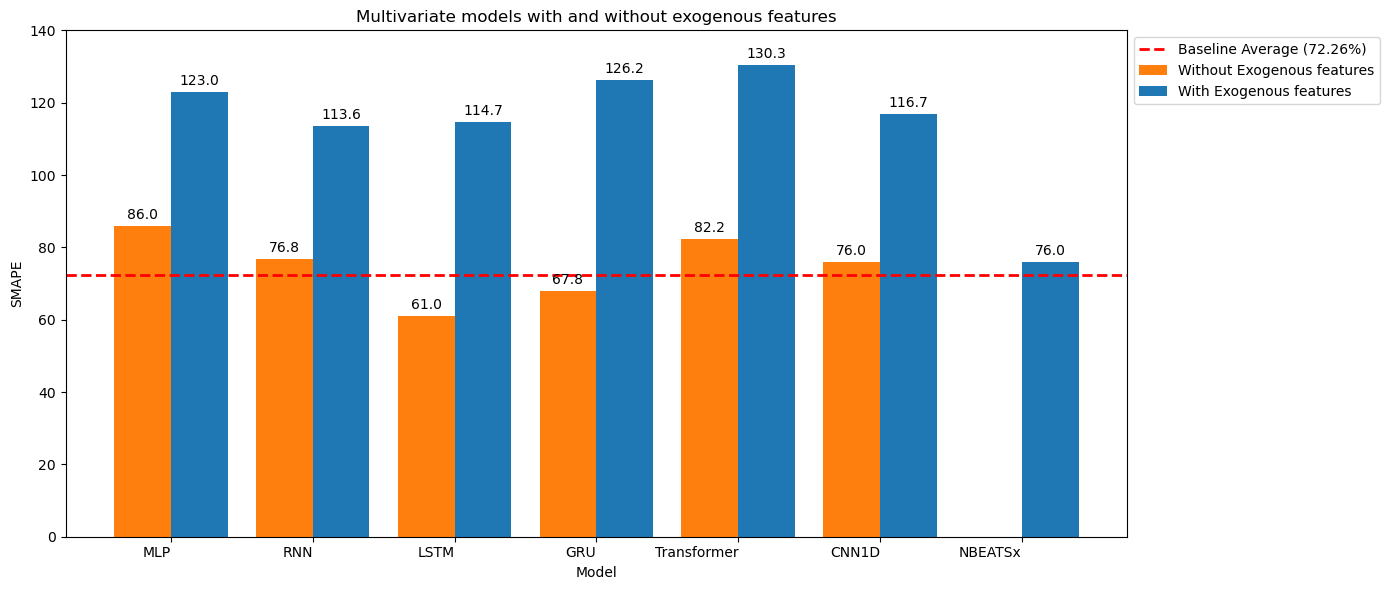

In [67]:
df_plot_multi = df_results[(df_results["Fold"]=="Average") & (df_results["Approach"]=="Multi")].copy()

pivot = df_plot_multi.pivot_table(
    index="Model",
    columns="Features",
    values="SMAPE",
    aggfunc="mean",
    observed=True
)

models = pivot.index.tolist()
x = np.arange(len(models))
width = 0.4

plt.figure(figsize=(14, 6))

bars_no = plt.bar(
    x - width/2,
    pivot["noExog"],
    width,
    label="Without Exogenous features",
    color="#ff7f0e"
)

bars_ex = plt.bar(
    x + width/2,
    pivot["Exog"],
    width,
    label="With Exogenous features",
    color="#1f77b4"
)

plt.axhline(
    y=72.26,
    linestyle="--",
    label="Baseline Average (72.26%)",
    linewidth=2,
    color="red"
)

plt.title("Multivariate models with and without exogenous features")
plt.xticks(x, models, rotation=0, ha="right")
plt.xlabel("Model")
plt.ylabel("SMAPE")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 140)


plt.bar_label(bars_no, fmt="%.1f", padding=3)
plt.bar_label(bars_ex, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()


The figure above presents the error metrics (SMAPE) of all trained multivariate models, representing the percentage forecasting error between observed and predicted values. Results are reported for models trained with exogenous features (blue) and without exogenous features (orange).

Among the multivariate models, the best forecasting performance was achieved by the LSTM (Long Short-Term Memory) model without exogenous features, with an average SMAPE of 61.0%. This best-performing multivariate model outperforms the best univariate model (RNN without exogenous features) by 6.2 percentage points, making it the best overall model evaluated in this project. Furthermore, it outperforms the baseline model (SMAPE = 72.3%), which predicts future values using the mean of the three previous observations, by 11.3 percentage points.

Consistent with the results observed for the univariate models, the highest SMAPE among the multivariate models was again recorded for the Transformer model with exogenous features, indicating that this architecture is the least suitable for predicting vehicle registration numbers in both the univariate and multivariate settings.

When comparing multivariate models trained with and without exogenous features, it becomes evident that models without exogenous features consistently achieve superior forecasting performance. Moreover, the comparison between univariate and multivariate approaches shows that the performance differences are substantially more pronounced in the multivariate case, which is largely attributable to the poor performance of multivariate models incorporating exogenous features.